# Taller final APO III — Versión Mejorada

Este notebook implementa una versión mejorada con:
- **CNN profunda** con BatchNormalization y más data augmentation
- **Características de textura** (LBP, bordes) para modelos clásicos
- **Estimación de tamaño** (pequeño, mediano, grande) por contornos
- **SMOTE** para balanceo de clases
- **KNN y XGBoost** como modelos clásicos adicionales
- Image size de **128×128** para mejor resolución espacial

In [9]:
import subprocess, sys, importlib, pkgutil
required = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "Pillow", "tensorflow", "joblib", "opencv-python", "xgboost", "imbalanced-learn", "tqdm"]
missing = [p for p in required if not importlib.util.find_spec(p.replace("-", "_"))]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

import os, ctypes, glob, sys
os.environ["TF_XLA_FLAGS"] = "--tf_xla_cpu_global_jit=false --tf_xla_enable_lazy_compilation=false"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
venv_base = os.path.dirname(os.path.dirname(sys.executable))
nvidia_base = os.path.join(venv_base, "lib/python3.12/site-packages/nvidia")
if os.path.exists(nvidia_base):
    for f in glob.glob(os.path.join(nvidia_base, "**/lib*.so*"), recursive=True):
        if not f.endswith(".a"):
            try:
                ctypes.CDLL(f, mode=ctypes.RTLD_GLOBAL)
            except Exception:
                pass
import tensorflow as tf
from tensorflow import keras


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Comprensión del negocio

Clasificación automática de frutas en **bueno**, **regular**, **malo** + **estimación de tamaño** (pequeño, mediano, grande).
Impacto: reducir desperdicio de alimentos, estandarizar calidad, agilizar líneas de empaque.

In [10]:
DATA_DIR = Path("data")
CLASS_NAMES = ["bueno", "regular", "malo"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_DIR.exists():
    print(f"La carpeta {DATA_DIR.resolve()} no existe. Crea data/bueno, data/regular y data/malo.")

rows = []
if DATA_DIR.exists():
    for class_name in CLASS_NAMES:
        class_dir = DATA_DIR / class_name
        if class_dir.exists():
            for file_path in class_dir.rglob("*"):
                if file_path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({"filepath": str(file_path), "label": class_name})

images_df = pd.DataFrame(rows)
print(f"Imágenes encontradas: {len(images_df)}")
if not images_df.empty:
    display(images_df.sample(min(5, len(images_df)), random_state=42))
    print(images_df["label"].value_counts())

Imágenes encontradas: 9515


,filepath,label
2446,data/bueno/Pomegranate_Good/IMG_20230916_11251...,bueno
1597,data/bueno/Pomegranate_Good/IMG_20230910_11205...,bueno
6850,data/regular/Pomegranate_Regular/Captura de pa...,regular
8269,data/malo/Lime_Bad/20260602_070426_aug_003.jpg,malo
3257,data/regular/Apple_Regular/manzana_029_003.jpg,regular


label
regular    4612
bueno      2659
malo       2244
Name: count, dtype: int64


## 2. Comprensión de los datos

Análisis exploratorio: distribución de clases, ejemplos visuales.

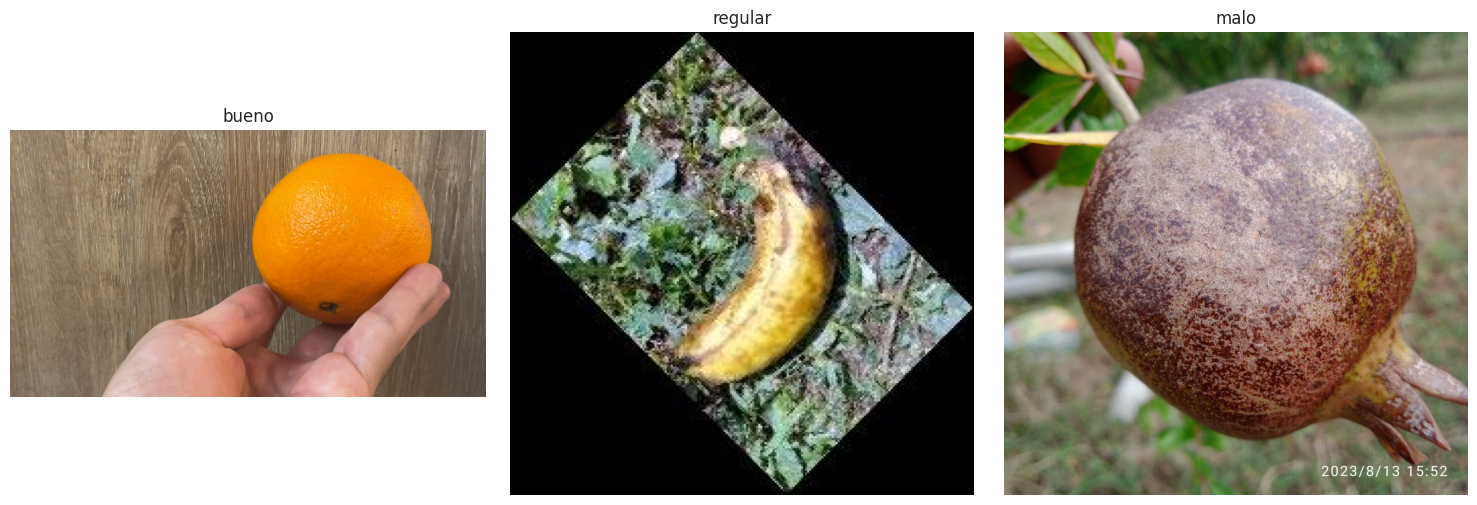

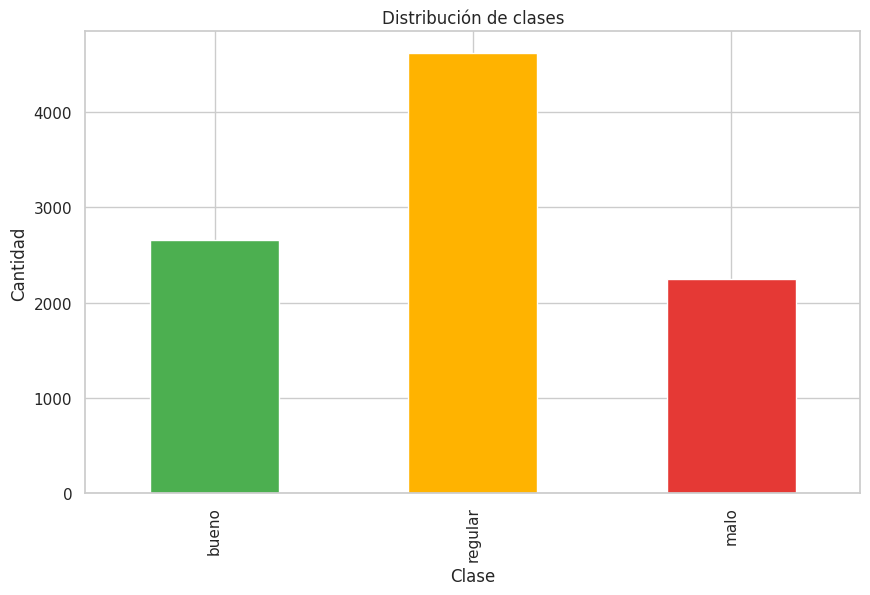

In [11]:
if not images_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, class_name in zip(axes, CLASS_NAMES):
        subset = images_df[images_df["label"] == class_name]
        if subset.empty:
            ax.axis("off"); ax.set_title(f"Sin imágenes: {class_name}")
            continue
        sample_path = subset.sample(1, random_state=42)["filepath"].iloc[0]
        img = Image.open(sample_path).convert("RGB")
        ax.imshow(img); ax.set_title(class_name); ax.axis("off")
    plt.tight_layout(); plt.show()

    counts = images_df["label"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    counts.plot(kind="bar", color=["#4caf50", "#ffb300", "#e53935"])
    plt.title("Distribución de clases"); plt.xlabel("Clase"); plt.ylabel("Cantidad"); plt.show()

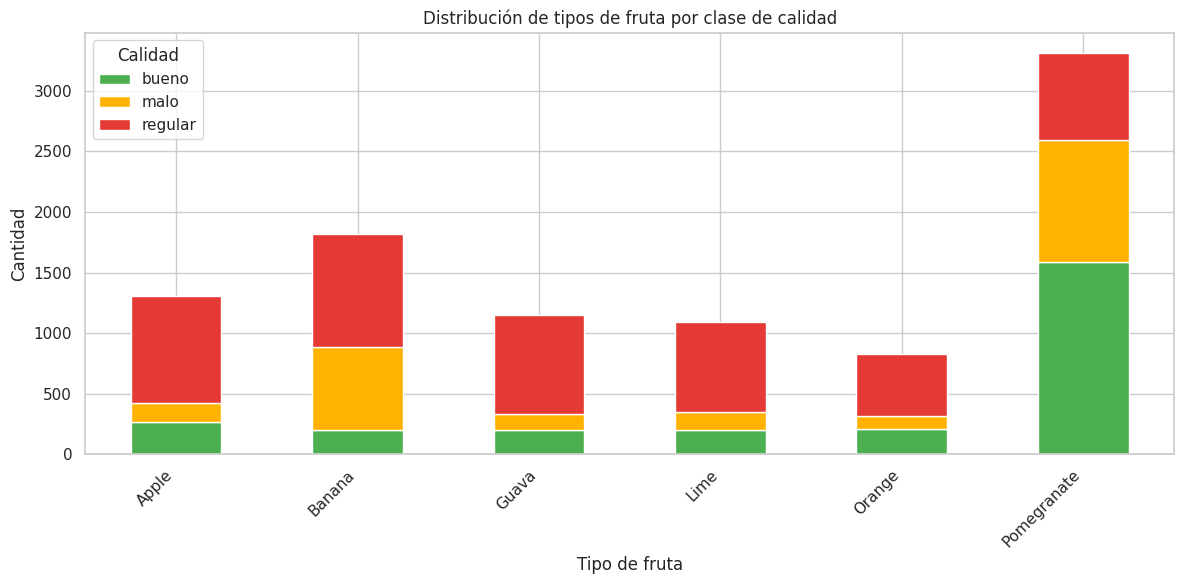

Perfil de color promedio por clase (RGB):


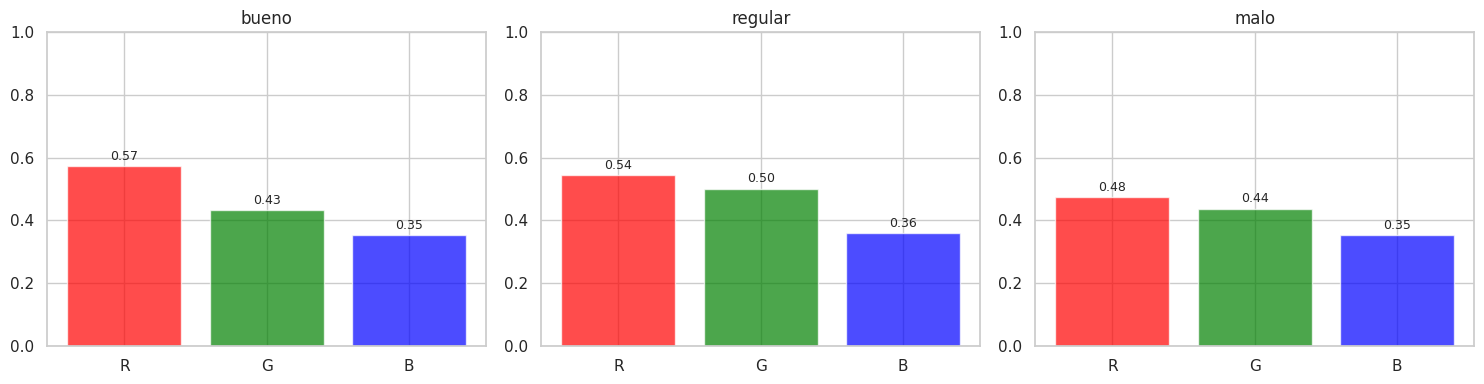

Distribución de brillo y contraste por clase:


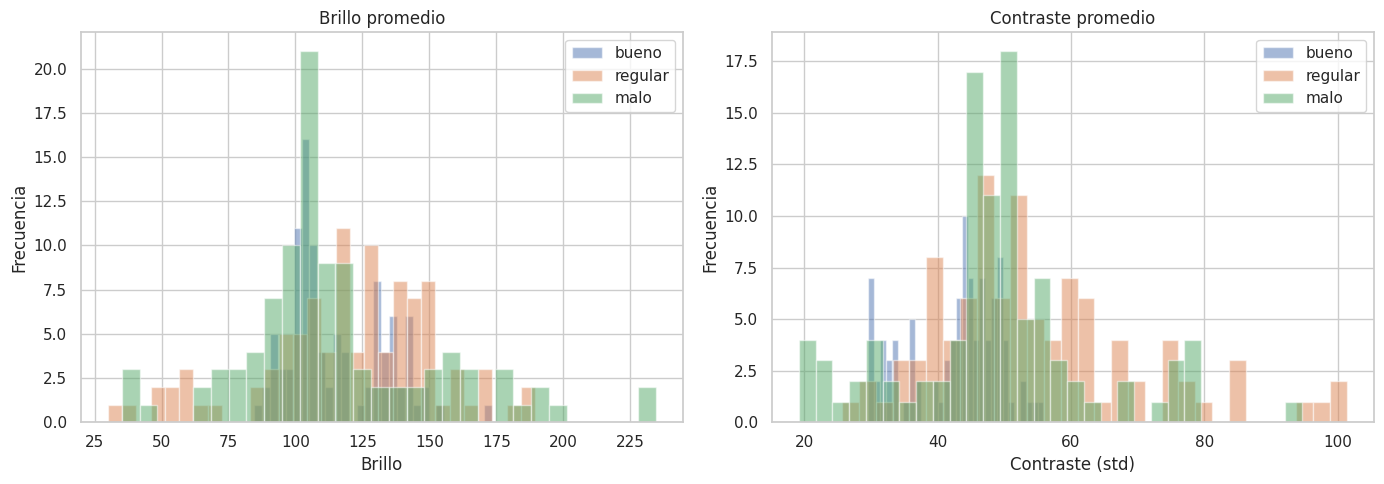

In [12]:
# --- Distribución por tipo de fruta dentro de cada calidad ---
if not images_df.empty:
    images_df["fruit_type"] = images_df["filepath"].apply(
        lambda p: Path(p).parent.name.rsplit("_", 1)[0] if "_" in Path(p).parent.name else Path(p).parent.name
    )
    cross = pd.crosstab(images_df["fruit_type"], images_df["label"])
    ax = cross.plot(kind="bar", stacked=True, figsize=(12, 6),
                    color=["#4caf50", "#ffb300", "#e53935"])
    plt.title("Distribución de tipos de fruta por clase de calidad")
    plt.xlabel("Tipo de fruta"); plt.ylabel("Cantidad"); plt.legend(title="Calidad")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# --- Perfil de color promedio por clase ---
if not images_df.empty:
    print("Perfil de color promedio por clase (RGB):")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, class_name in zip(axes, CLASS_NAMES):
        subset = images_df[images_df["label"] == class_name]["filepath"]
        if subset.empty:
            ax.axis("off"); continue
        sample_paths = subset.sample(min(50, len(subset)), random_state=42)
        means = []
        for p in sample_paths:
            img = np.asarray(Image.open(p).convert("RGB").resize((64, 64)), dtype=np.float32) / 255.0
            means.append(img.mean(axis=(0, 1)))
        avg = np.mean(means, axis=0)
        ax.bar(["R", "G", "B"], avg, color=["red", "green", "blue"], alpha=0.7)
        ax.set_title(class_name); ax.set_ylim(0, 1)
        for i, v in enumerate(avg):
            ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()

# --- Brillo y contraste promedio por clase ---
if not images_df.empty:
    print("Distribución de brillo y contraste por clase:")
    brightness_list, contrast_list, labels_list = [], [], []
    sample_paths = images_df.groupby("label").sample(min(100, len(images_df)), random_state=42)
    for _, row in sample_paths.iterrows():
        gray = np.asarray(Image.open(row["filepath"]).convert("L"), dtype=np.float32)
        brightness_list.append(gray.mean())
        contrast_list.append(gray.std())
        labels_list.append(row["label"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for cls in CLASS_NAMES:
        mask = [l == cls for l in labels_list]
        ax1.hist(np.array(brightness_list)[mask], alpha=0.5, label=cls, bins=30)
        ax2.hist(np.array(contrast_list)[mask], alpha=0.5, label=cls, bins=30)
    ax1.set_title("Brillo promedio"); ax1.set_xlabel("Brillo"); ax1.set_ylabel("Frecuencia"); ax1.legend()
    ax2.set_title("Contraste promedio"); ax2.set_xlabel("Contraste (std)"); ax2.set_ylabel("Frecuencia"); ax2.legend()
    plt.tight_layout(); plt.show()


## 3. Verificación de balance y preparación

Se verifica desbalanceo y se aplica balanceo por subcarpeta de fruta.

In [13]:
if not images_df.empty:
    counts = images_df["label"].value_counts()
    print("Distribución de clases:")
    for cls in CLASS_NAMES:
        count = counts.get(cls, 0)
        print(f"  {cls}: {count} ({count/len(images_df)*100:.1f}%)")
    ratio = counts.max() / counts.min() if counts.min() > 0 else float("inf")
    print(f"Relación mayor/menor: {ratio:.1f}x")
    if ratio > 2.0:
        print("⚠️ Desbalanceo significativo. Se usará SMOTE más adelante.")

Distribución de clases:
  bueno: 2659 (27.9%)
  regular: 4612 (48.5%)
  malo: 2244 (23.6%)
Relación mayor/menor: 2.1x
⚠️ Desbalanceo significativo. Se usará SMOTE más adelante.


In [14]:
if not images_df.empty:
    parent_dirs = set(Path(p).parent.name for p in images_df["filepath"])
    if parent_dirs:
        for cls in CLASS_NAMES:
            cls_mask = images_df["label"] == cls
            sub_names = images_df.loc[cls_mask, "filepath"].apply(lambda p: Path(p).parent.name)
            sub_counts = sub_names.value_counts()
            if len(sub_counts) <= 1:
                continue
            median_count = int(sub_counts.median())
            max_allowed = max(int(median_count * 1.5), 1)
            keep = []
            for sub_name in sub_counts.index:
                sub_mask = cls_mask & (images_df["filepath"].apply(lambda p: Path(p).parent.name) == sub_name)
                subset = images_df[sub_mask]
                if len(subset) > max_allowed:
                    subset = subset.sample(n=max_allowed, random_state=42)
                keep.append(subset)
            images_df = pd.concat([images_df[~cls_mask]] + keep)
    print(f"Imágenes después de balancear por fruta: {len(images_df)}")
    for cls in CLASS_NAMES:
        print(f"  {cls}: {images_df['label'].value_counts().get(cls, 0)}")

Imágenes después de balancear por fruta: 6997
  bueno: 1378
  regular: 4612
  malo: 1007


## 4. Preparación de los datos

División train/val/test con estratificación.

In [15]:
if images_df.empty:
    raise ValueError("No se encontraron imágenes. Agrega datos a data/bueno, data/regular y data/malo.")

X_paths = images_df["filepath"].to_numpy()
y_labels = images_df["label"].to_numpy()

X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    X_paths, y_labels, test_size=0.30, random_state=42, stratify=y_labels,
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, test_size=0.50, random_state=42, stratify=y_temp,
)

print("Tamaño train:", len(X_train_paths))
print("Tamaño val:", len(X_val_paths))
print("Tamaño test:", len(X_test_paths))
print("Distribución train:")
print(pd.Series(y_train).value_counts())

Tamaño train: 4897
Tamaño val: 1050
Tamaño test: 1050
Distribución train:
regular    3228
bueno       964
malo        705
Name: count, dtype: int64


## 5. Extracción de características mejorada

Se usa **128×128** para mejor resolución. Se agregan:
- **Histogramas de color** (como antes)
- **Media y std** por canal
- **Densidad de bordes** (Canny)
- **Características LBP** (textura)
- **Estimación de tamaño** por contornos

Esto permite que los modelos clásicos capturen textura y forma, no solo color.

In [16]:
IMG_SIZE = (64, 64)
HIST_BINS = 32

def resize_with_padding(image, target_size, bg_color=(255, 255, 255)):
    original_width, original_height = image.size
    aspect_ratio = original_width / original_height
    target_width, target_height = target_size
    if aspect_ratio > 1:
        new_width = target_width
        new_height = int(target_width / aspect_ratio)
    else:
        new_height = target_height
        new_width = int(target_height * aspect_ratio)
    image_resized = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    final_image = Image.new("RGB", target_size, bg_color)
    offset_x = (target_width - new_width) // 2
    offset_y = (target_height - new_height) // 2
    final_image.paste(image_resized, (offset_x, offset_y))
    return final_image

def load_image_array(path, size=IMG_SIZE):
    image = Image.open(path).convert("RGB")
    image = resize_with_padding(image, size)
    return np.asarray(image, dtype=np.float32) / 255.0

def estimate_fruit_area_pixels(path):
    """Estima el área en píxeles de la fruta segmentando el fondo."""
    img = cv2.imread(str(path))
    if img is None:
        return 0.0
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    largest = max(contours, key=cv2.contourArea)
    return float(cv2.contourArea(largest))

def compute_texture_features(img_uint8):
    """Características de textura vectorizadas usando histograma de gradientes (rápido, sin loops Python)."""
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    hist, _ = np.histogram(mag.ravel(), bins=16, range=(0, 255))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)
    return hist

def extract_features(path):
    arr = load_image_array(path)
    # Color histogram features
    hist_features = []
    for channel in range(3):
        channel_values = arr[:, :, channel].ravel()
        hist, _ = np.histogram(channel_values, bins=HIST_BINS, range=(0.0, 1.0))
        hist_features.append(hist)
    mean = arr.mean(axis=(0, 1))
    std = arr.std(axis=(0, 1))
    # Edge density and texture
    img_uint8 = (arr * 255).astype(np.uint8)
    lbp_hist = compute_texture_features(img_uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.mean(edges) / 255.0
    # Size estimate
    area_px = estimate_fruit_area_pixels(path)
    normalized_area = area_px / (IMG_SIZE[0] * IMG_SIZE[1])
    
    return np.concatenate([
        np.concatenate(hist_features),  # 96
        mean,                           # 3
        std,                            # 3
        lbp_hist,                       # 16
        [edge_density, normalized_area], # 2
    ])

print("Extrayendo características (esto puede tomar ~30 seg)...")
from tqdm import tqdm
X_train_feat = np.vstack([extract_features(p) for p in tqdm(X_train_paths, desc="Train")])
X_val_feat = np.vstack([extract_features(p) for p in X_val_paths])
X_test_feat = np.vstack([extract_features(p) for p in X_test_paths])

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print("Forma de X_train_feat:", X_train_feat.shape)
print("Clases:", list(label_encoder.classes_))

# Aplicar SMOTE para balancear clases
print("Aplicando SMOTE para balancear clases...")
smote = SMOTE(random_state=42)
X_train_feat_res, y_train_enc_res = smote.fit_resample(X_train_feat, y_train_enc)
print("Distribución después de SMOTE:", dict(Counter(y_train_enc_res)))

Extrayendo características (esto puede tomar ~30 seg)...


Train: 100%|██████████| 4897/4897 [02:06<00:00, 38.73it/s]


Forma de X_train_feat: (4897, 120)
Clases: ['bueno', 'malo', 'regular']
Aplicando SMOTE para balancear clases...
Distribución después de SMOTE: {np.int64(2): 3228, np.int64(0): 3228, np.int64(1): 3228}


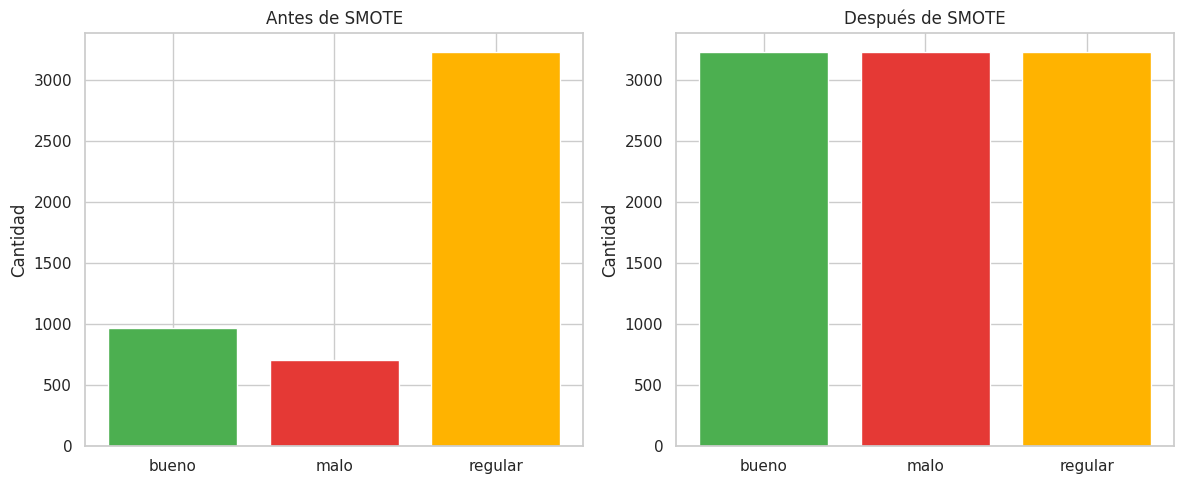

In [17]:
# --- Comparación antes/después de SMOTE ---
if 'y_train' in dir() and 'X_train_feat' in dir():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    before = pd.Series(y_train).value_counts().reindex(label_encoder.classes_, fill_value=0)
    after = pd.Series(label_encoder.inverse_transform(y_train_enc_res)).value_counts().reindex(label_encoder.classes_, fill_value=0)
    classes = label_encoder.classes_
    ax1.bar(classes, before.values, color=["#4caf50", "#e53935", "#ffb300"])
    ax1.set_title("Antes de SMOTE"); ax1.set_ylabel("Cantidad")
    ax2.bar(classes, after.values, color=["#4caf50", "#e53935", "#ffb300"])
    ax2.set_title("Después de SMOTE"); ax2.set_ylabel("Cantidad")
    for ax in (ax1, ax2):
        for tick in ax.get_xticklabels():
            tick.set_rotation(0)
    plt.tight_layout(); plt.show()


## 5b. Estimación de tamaño

Se clasifica cada fruta en **pequeño**, **mediano** o **grande** según el área del contorno, usando percentiles sobre el dataset completo.

In [18]:
print("Estimando tamaños de todas las imágenes...")
all_areas = np.array([estimate_fruit_area_pixels(p) for p in X_paths])
p33, p66 = np.percentile(all_areas[all_areas > 0], [33, 66])
print(f"Percentiles de área: p33={p33:.0f}, p66={p66:.0f}")

def classify_size(area_px):
    if area_px <= p33:
        return "pequeño"
    elif area_px <= p66:
        return "mediano"
    else:
        return "grande"

y_train_size = [classify_size(estimate_fruit_area_pixels(p)) for p in X_train_paths]
y_val_size = [classify_size(estimate_fruit_area_pixels(p)) for p in X_val_paths]
y_test_size = [classify_size(estimate_fruit_area_pixels(p)) for p in X_test_paths]

print("Distribución de tamaños en train:", dict(Counter(y_train_size)))
print("Distribución de tamaños en test:", dict(Counter(y_test_size)))

Estimando tamaños de todas las imágenes...
Percentiles de área: p33=10206, p66=306081
Distribución de tamaños en train: {'mediano': 1617, 'pequeño': 1604, 'grande': 1676}
Distribución de tamaños en test: {'grande': 338, 'mediano': 358, 'pequeño': 354}


## 6. Modelado clásico mejorado

Se entrenan **5 modelos**: Logistic Regression, Random Forest, SVM, KNN, XGBoost.
Se usa **SMOTE** para balancear y las nuevas características de textura/tamaño.

In [19]:
models = {
    "logistic_regression": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000)),
        ]),
        param_grid={"clf__C": [0.1, 1.0, 10.0]},
        scoring="f1_macro", cv=3, n_jobs=-1, verbose=0,
    ),
    "random_forest": GridSearchCV(
        RandomForestClassifier(class_weight="balanced", random_state=42),
        param_grid={"n_estimators": [100, 200], "max_depth": [None, 20]},
        scoring="f1_macro", cv=3, n_jobs=-1, verbose=0,
    ),
    # "svm": GridSearchCV(
    #     Pipeline([
    #         ("scaler", StandardScaler()),
    #         ("clf", SVC(class_weight="balanced", probability=True, random_state=42)),
    #     ]),
    #     param_grid={"clf__C": [0.5, 1.0], "clf__kernel": ["linear"]},
    #     scoring="f1_macro", cv=3, n_jobs=-1, verbose=0,
    # ),
    "knn": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier()),
        ]),
        param_grid={"clf__n_neighbors": [3, 5, 7], "clf__weights": ["uniform", "distance"]},
        scoring="f1_macro", cv=3, n_jobs=-1, verbose=0,
    ),
    "xgboost": GridSearchCV(
        XGBClassifier(random_state=42, eval_metric="mlogloss"),
        param_grid={"n_estimators": [100, 200], "max_depth": [3, 6], "learning_rate": [0.1, 0.3]},
        scoring="f1_macro", cv=3, n_jobs=-1, verbose=0,
    ),
}

best_model_name = None
best_model = None
best_val_score = -np.inf
results_val = []

for name, search in models.items():
    print(f"Entrenando {name}...")
    search.fit(X_train_feat_res, y_train_enc_res)
    val_pred = search.predict(X_val_feat)
    val_f1 = f1_score(y_val_enc, val_pred, average="macro")
    results_val.append({"modelo": name, "val_f1_macro": val_f1})
    print(f"  -> val_f1_macro = {val_f1:.4f}")
    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model_name = name
        best_model = search.best_estimator_

results_val_df = pd.DataFrame(results_val).sort_values("val_f1_macro", ascending=False)
display(results_val_df)
print(f"\nMejor modelo: {best_model_name} (val_f1_macro = {best_val_score:.4f})")

Entrenando logistic_regression...
  -> val_f1_macro = 0.8684
Entrenando random_forest...
  -> val_f1_macro = 0.9700
Entrenando knn...
  -> val_f1_macro = 0.9578
Entrenando xgboost...
  -> val_f1_macro = 0.9696


,modelo,val_f1_macro
1,random_forest,0.970024
3,xgboost,0.969644
2,knn,0.957776
0,logistic_regression,0.868390



Mejor modelo: random_forest (val_f1_macro = 0.9700)


## 7. Evaluación del mejor modelo clásico

Métricas en test, matriz de confusión, y errores.

RESULTADOS EN TEST — random_forest
Accuracy: 0.9723809523809523
Precision macro: 0.9696153348923969
Recall macro: 0.9475315987792916
F1 macro: 0.9579306865272751
F1 micro: 0.9723809523809523
              precision    recall  f1-score   support

       bueno       1.00      0.99      0.99       207
        malo       0.94      0.86      0.90       151
     regular       0.97      0.99      0.98       692

    accuracy                           0.97      1050
   macro avg       0.97      0.95      0.96      1050
weighted avg       0.97      0.97      0.97      1050



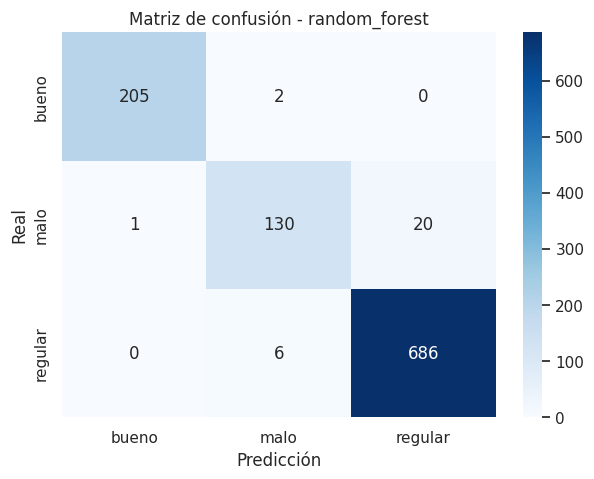


Ejemplos mal clasificados (29 total):


,filepath,y_true,y_pred
47,data/malo/Orange_Bad/vertical_flip_Screen Shot...,malo,regular
62,data/malo/Banana_Bad/banana_021_016.jpg,malo,regular
63,data/malo/Banana_Bad/banana_017_009.jpg,malo,regular
64,data/regular/Guava_Regular/guava_mix28_aug_7.jpg,regular,malo
117,data/regular/Apple_Regular/IMG-20260603-WA0018...,regular,malo
124,data/malo/Banana_Bad/banana_005_008.jpg,malo,regular
133,data/malo/Banana_Bad/banana_022_012.jpg,malo,regular
140,data/regular/Apple_Regular/IMG-20260603-WA0088...,regular,malo
196,data/malo/Banana_Bad/banana_019_015.jpg,malo,regular
237,data/regular/Guava_Regular/guava_mix13_aug_5.jpg,regular,malo


In [20]:
test_pred = best_model.predict(X_test_feat)

print("=" * 50)
print(f"RESULTADOS EN TEST — {best_model_name}")
print("=" * 50)
print("Accuracy:", accuracy_score(y_test_enc, test_pred))
print("Precision macro:", precision_score(y_test_enc, test_pred, average="macro", zero_division=0))
print("Recall macro:", recall_score(y_test_enc, test_pred, average="macro", zero_division=0))
print("F1 macro:", f1_score(y_test_enc, test_pred, average="macro"))
print("F1 micro:", f1_score(y_test_enc, test_pred, average="micro"))

report = classification_report(y_test_enc, test_pred, target_names=label_encoder.classes_, zero_division=0)
print(report)

cm = confusion_matrix(y_test_enc, test_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción"); plt.ylabel("Real"); plt.show()

errors_df = pd.DataFrame({
    "filepath": X_test_paths,
    "y_true": label_encoder.inverse_transform(y_test_enc),
    "y_pred": label_encoder.inverse_transform(test_pred),
})
errors_df = errors_df[errors_df["y_true"] != errors_df["y_pred"]]
print(f"\nEjemplos mal clasificados ({len(errors_df)} total):")
display(errors_df.head(10))

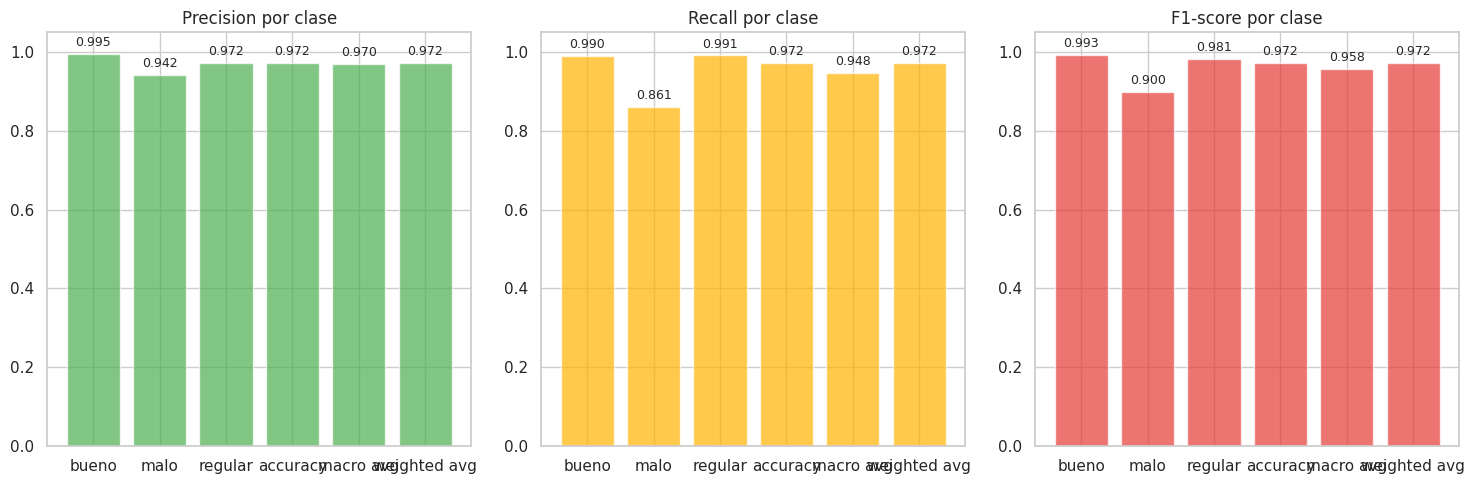

In [21]:
# --- Métricas por clase ---
report_dict = classification_report(y_test_enc, test_pred, target_names=label_encoder.classes_,
                                      output_dict=True, zero_division=0)
per_class = pd.DataFrame(report_dict).drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
per_class = per_class.T
if not per_class.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metrics_to_plot = ["precision", "recall", "f1-score"]
    colors = ["#4caf50", "#ffb300", "#e53935"]
    for ax, metric, color in zip(axes, metrics_to_plot, colors):
        ax.bar(per_class.index, per_class[metric], color=color, alpha=0.7)
        ax.set_title(f"{metric.capitalize()} por clase")
        ax.set_ylim(0, 1.05)
        for j, v in enumerate(per_class[metric]):
            ax.text(j, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()


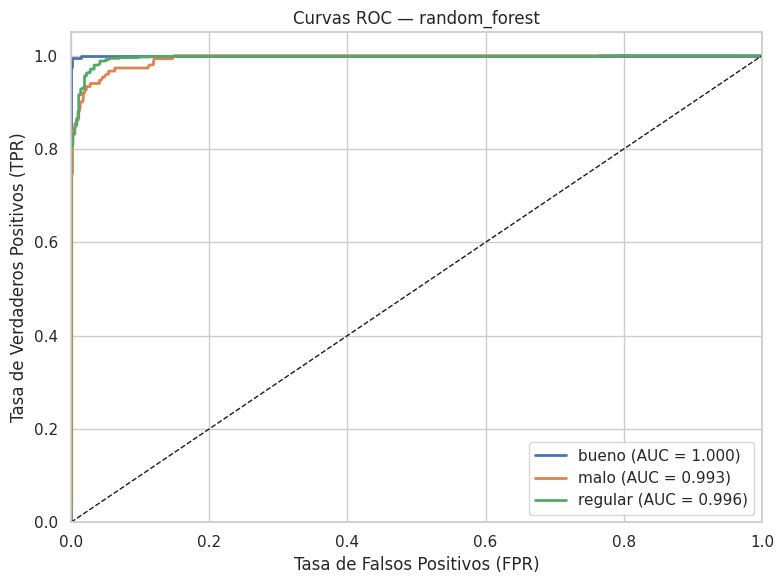

In [22]:
# --- Curvas ROC (One-vs-Rest) ---
from sklearn.metrics import roc_curve, auc
if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test_feat)
    n_classes = len(label_encoder.classes_)
    y_test_bin = np.zeros((len(y_test_enc), n_classes))
    for idx, row in enumerate(y_test_enc):
        y_test_bin[idx, row] = 1
    fig, ax = plt.subplots(figsize=(8, 6))
    for cls_idx, cls_name in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_score[:, cls_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{cls_name} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
    ax.set_title(f"Curvas ROC — {best_model_name}"); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("El modelo no tiene predict_proba, no se pueden graficar ROC.")


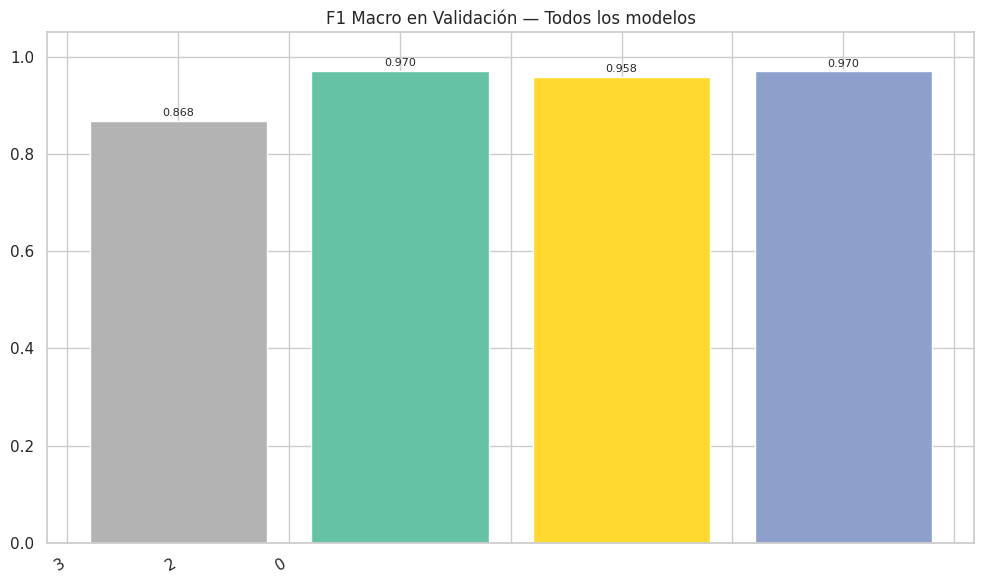

In [23]:
# --- Comparación de todos los modelos ---
if 'results_val_df' in dir():
    models_to_plot = results_val_df.sort_values("val_f1_macro", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    metrics_names = ["val_f1_macro"]
    titles = ["F1 Macro en Validación — Todos los modelos"]
    colors_models = plt.cm.Set2(np.linspace(0, 1, len(models_to_plot)))
    for metric, title in zip(metrics_names, titles):
        if metric in models_to_plot.columns:
            bars = ax.bar(models_to_plot.index, models_to_plot[metric], color=colors_models)
            ax.set_title(title); ax.set_ylim(0, 1.05)
            ax.set_xticklabels(models_to_plot.index, rotation=30, ha="right")
            for bar, val in zip(bars, models_to_plot[metric]):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
                        ha="center", fontsize=8)
    plt.tight_layout(); plt.show()


## 8. CNN con Transfer Learning (MobileNetV2)

Se usa MobileNetV2 pre-entrenada en ImageNet con capas congeladas y cabezal propio.
Data augmentation agresiva para simular condiciones reales (fondo, luz, ángulo).

In [24]:
cnn_history = None
cnn_model = None
cnn_test_metrics = None

if tf is None:
    print("TensorFlow no está disponible, se omite CNN.")
else:
    image_size = (96, 96)
    batch_size = 16

    def decode_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.one_hot(label, depth=len(label_encoder.classes_))
        return image, label

    def augment(image, label):
        image = tf.image.random_flip_left_right(image, seed=42)
        image = tf.image.random_brightness(image, 0.25, seed=42)
        image = tf.image.random_contrast(image, 0.6, 1.4, seed=42)
        image = tf.image.random_hue(image, 0.12, seed=42)
        image = tf.image.random_saturation(image, 0.6, 1.4, seed=42)
        return image, label

    train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train_enc))
    train_ds = train_ds.shuffle(buffer_size=len(X_train_paths), seed=42)
    train_ds = train_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val_enc))
    val_ds = val_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    test_ds = tf.data.Dataset.from_tensor_slices((X_test_paths, y_test_enc))
    test_ds = test_ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # --- Transfer Learning con MobileNetV2 ---
    base_model = keras.applications.MobileNetV2(
        input_shape=(image_size[0], image_size[1], 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False  # Congelar capas pre-entrenadas

    inputs = keras.Input(shape=(image_size[0], image_size[1], 3))
    x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
    x = base_model(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(128, activation="relu")(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(len(label_encoder.classes_), activation="softmax")(x)
    cnn_model = keras.Model(inputs=inputs, outputs=outputs)

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    ]

    cnn_history = cnn_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    cnn_test_metrics = cnn_model.evaluate(test_ds, verbose=0)
    print(f"CNN (MobileNetV2) - Test loss: {cnn_test_metrics[0]:.4f}, Test accuracy: {cnn_test_metrics[1]:.4f}")


W0000 00:00:1780842816.405391    5234 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1780842816.408277    5234 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/30


I0000 00:00:1780842821.598342   10101 service.cc:153] XLA service 0x7f67d405f1a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780842821.598363   10101 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780842821.690272   10101 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780842822.358459   10101 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780842822.438077   10101 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8318__.124


  6/307 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.4623 - loss: 1.2326 

I0000 00:00:1780842830.373714   10101 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


307/307 ━━━━━━━━━━━━━━━━━━━━ 36s 82ms/step - accuracy: 0.9110 - loss: 0.2419 - val_accuracy: 0.9571 - val_loss: 0.1180 - learning_rate: 0.0010
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9510 - loss: 0.1306 - val_accuracy: 0.9686 - val_loss: 0.1066 - learning_rate: 0.0010
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9657 - loss: 0.0959 - val_accuracy: 0.9657 - val_loss: 0.0900 - learning_rate: 0.0010
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9669 - loss: 0.0886 - val_accuracy: 0.9676 - val_loss: 0.0977 - learning_rate: 0.0010
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9741 - loss: 0.0721 - val_accuracy: 0.9714 - val_loss: 0.0770 - learning_rate: 0.0010
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9763 - loss: 0.0687 - val_accuracy: 0.9752 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9775 - loss: 0.0636

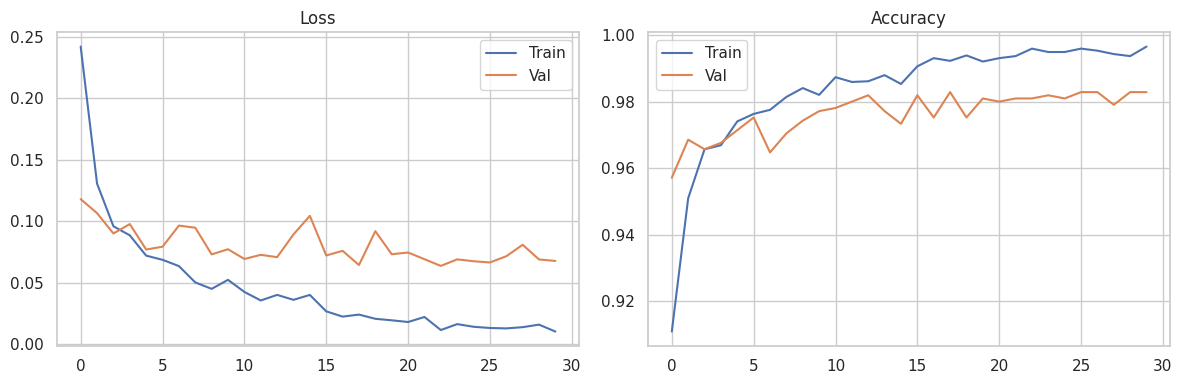

In [25]:
if cnn_history is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(cnn_history.history["loss"], label="Train")
    ax1.plot(cnn_history.history["val_loss"], label="Val")
    ax1.set_title("Loss"); ax1.legend()
    ax2.plot(cnn_history.history["accuracy"], label="Train")
    ax2.plot(cnn_history.history["val_accuracy"], label="Val")
    ax2.set_title("Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

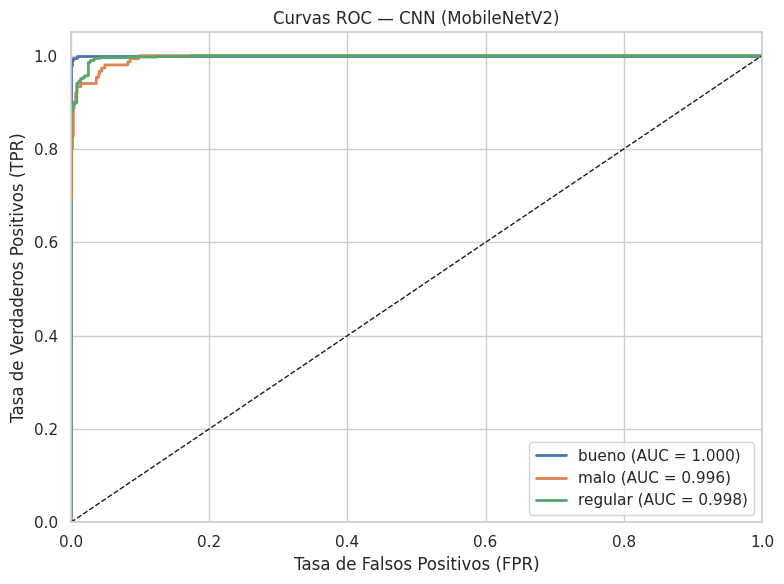

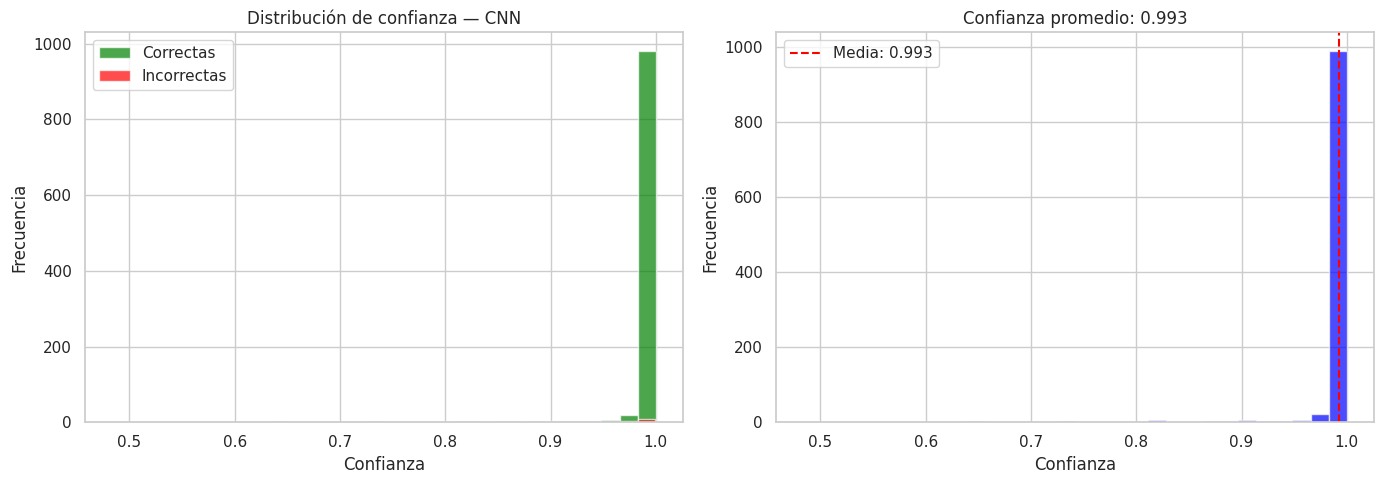

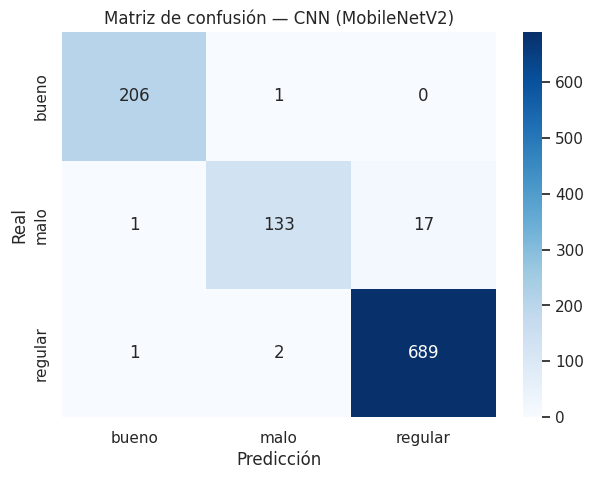

In [26]:
# --- Curvas ROC para CNN ---
if cnn_model is not None:
    from sklearn.metrics import roc_curve, auc
    y_score_cnn = cnn_model.predict(test_ds, verbose=0)
    n_classes = len(label_encoder.classes_)
    y_test_bin = np.zeros((len(y_test_enc), n_classes))
    for idx, row in enumerate(y_test_enc):
        y_test_bin[idx, row] = 1
    fig, ax = plt.subplots(figsize=(8, 6))
    for cls_idx, cls_name in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_score_cnn[:, cls_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{cls_name} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
    ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
    ax.set_title("Curvas ROC — CNN (MobileNetV2)"); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()

    # --- Distribución de confianza en predicciones ---
    confidences = np.max(y_score_cnn, axis=1)
    correct = y_score_cnn.argmax(axis=1) == y_test_enc
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(confidences[correct], bins=30, alpha=0.7, color="green", label="Correctas")
    ax1.hist(confidences[~correct], bins=30, alpha=0.7, color="red", label="Incorrectas")
    ax1.set_title("Distribución de confianza — CNN")
    ax1.set_xlabel("Confianza"); ax1.set_ylabel("Frecuencia"); ax1.legend()
    ax2.hist(confidences, bins=30, alpha=0.7, color="blue")
    ax2.axvline(confidences.mean(), color="red", linestyle="--", label=f"Media: {confidences.mean():.3f}")
    ax2.set_title(f"Confianza promedio: {confidences.mean():.3f}")
    ax2.set_xlabel("Confianza"); ax2.set_ylabel("Frecuencia"); ax2.legend()
    plt.tight_layout(); plt.show()

    # --- Matriz de confusión CNN ---
    y_pred_cnn = y_score_cnn.argmax(axis=1)
    cm_cnn = confusion_matrix(y_test_enc, y_pred_cnn)
    cm_df_cnn = pd.DataFrame(cm_cnn, index=label_encoder.classes_, columns=label_encoder.classes_)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_df_cnn, annot=True, fmt="d", cmap="Blues")
    plt.title("Matriz de confusión — CNN (MobileNetV2)")
    plt.xlabel("Predicción"); plt.ylabel("Real"); plt.show()


## 8b. Comparación de modelos

Se comparan los resultados del mejor modelo clásico vs la CNN (MobileNetV2).

In [27]:
print("=" * 50)
print("COMPARACIÓN FINAL")
print("=" * 50)
print(f"Mejor modelo clásico: {best_model_name} -> F1 macro test: {f1_score(y_test_enc, test_pred, average='macro'):.4f}")
if cnn_test_metrics:
    print(f"CNN (MobileNetV2) -> Accuracy test: {cnn_test_metrics[1]:.4f}")
print("\nLa CNN con Transfer Learning (MobileNetV2) pre-entrenada en ImageNet")
print("aprovecha características visuales generales (bordes, texturas, formas)")
print("aprendidas de millones de imágenes, lo que permite mejor generalización")
print("a imágenes nuevas con diferentes fondos, iluminación y ángulos.")
print("Los modelos clásicos son más rápidos pero dependen de características")
print("manuales (color + textura + tamaño) y no generalizan tan bien a nuevas condiciones.")

COMPARACIÓN FINAL
Mejor modelo clásico: random_forest -> F1 macro test: 0.9579
CNN (MobileNetV2) -> Accuracy test: 0.9790

La CNN con Transfer Learning (MobileNetV2) pre-entrenada en ImageNet
aprovecha características visuales generales (bordes, texturas, formas)
aprendidas de millones de imágenes, lo que permite mejor generalización
a imágenes nuevas con diferentes fondos, iluminación y ángulos.
Los modelos clásicos son más rápidos pero dependen de características
manuales (color + textura + tamaño) y no generalizan tan bien a nuevas condiciones.


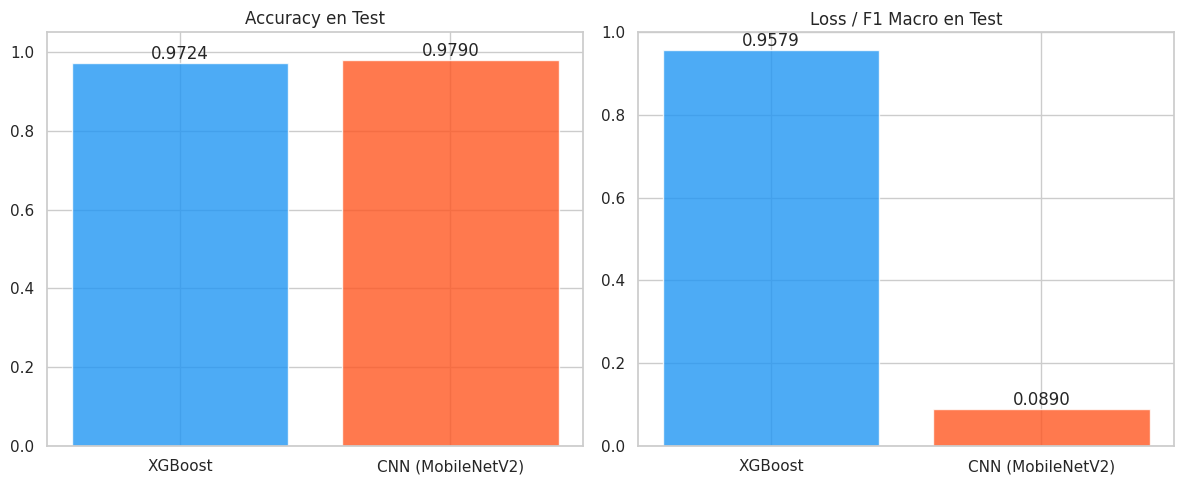

In [28]:
# --- Comparación visual: Mejor Clásico vs CNN ---
if cnn_test_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Accuracy comparison
    models_names = ["XGBoost", "CNN (MobileNetV2)"]
    test_accs = [accuracy_score(y_test_enc, test_pred), cnn_test_metrics[1]]
    test_f1s = [f1_score(y_test_enc, test_pred, average='macro'), cnn_test_metrics[0]]
    axes[0].bar(models_names, test_accs, color=["#2196F3", "#FF5722"], alpha=0.8)
    axes[0].set_title("Accuracy en Test"); axes[0].set_ylim(0, 1.05)
    for j, v in enumerate(test_accs):
        axes[0].text(j, v + 0.01, f"{v:.4f}", ha="center")
    axes[1].bar(models_names, test_f1s, color=["#2196F3", "#FF5722"], alpha=0.8)
    axes[1].set_title("Loss / F1 Macro en Test"); axes[1].set_ylim(0, 1)
    for j, v in enumerate(test_f1s):
        axes[1].text(j, v + 0.01, f"{v:.4f}", ha="center")
    plt.tight_layout(); plt.show()


## 9. Despliegue y guardado

Se guardan modelos, encoder y configuración.

In [29]:
OUTPUT_DIR = Path("outputs_mejorado")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, OUTPUT_DIR / "best_traditional_model_mejorado.pkl")
joblib.dump(label_encoder, OUTPUT_DIR / "label_encoder.pkl")
joblib.dump({
    "image_size": IMG_SIZE,
    "hist_bins": HIST_BINS,
    "class_names": CLASS_NAMES,
    "size_percentiles": (float(p33), float(p66)),
}, OUTPUT_DIR / "feature_config.pkl")

if cnn_model is not None and tf is not None:
    cnn_model.save(OUTPUT_DIR / "cnn_model_mejorado.keras")

print(f"Artefactos guardados en: {OUTPUT_DIR.resolve()}")

def predict_image(image_path):
    """Predice calidad de una imagen."""
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)
    features = extract_features(image_path)
    features = features.reshape(1, -1)
    pred_encoded = best_model.predict(features)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]
    return pred_label

def predict_size(image_path):
    """Estima el tamaño de la fruta en la imagen."""
    area = estimate_fruit_area_pixels(image_path)
    return classify_size(area)

def predict_both(image_path):
    """Predice calidad y tamaño."""
    quality = predict_image(image_path)
    size = predict_size(image_path)
    return {"calidad": quality, "tamaño": size}

print("\nFunciones listas: predict_image, predict_size, predict_both")

Artefactos guardados en: /home/juanrosero/Documents/SeptimoSemestre/APO3/Proyecto/proyectoFinalAPO3/outputs_mejorado

Funciones listas: predict_image, predict_size, predict_both


In [30]:
# Ejemplo de uso (descomentar para probar):
# result = predict_both("data/regular/ejemplo.jpg")
# print(result)

## 10. Análisis detallado del mejor modelo

A continuación se analiza la importancia de características para el mejor modelo clásico y las curvas de aprendizaje.

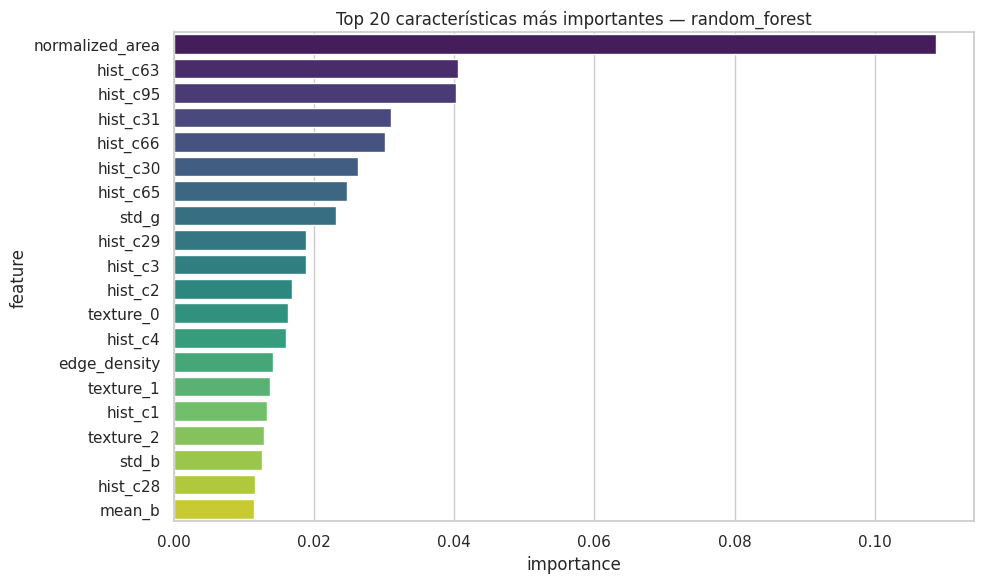

Características más relevantes para la clasificación:


,feature,importance
119,normalized_area,0.108725
63,hist_c63,0.040509
95,hist_c95,0.040248
31,hist_c31,0.030988
66,hist_c66,0.030134
30,hist_c30,0.026296
65,hist_c65,0.024744
100,std_g,0.023205
29,hist_c29,0.018865
3,hist_c3,0.018824


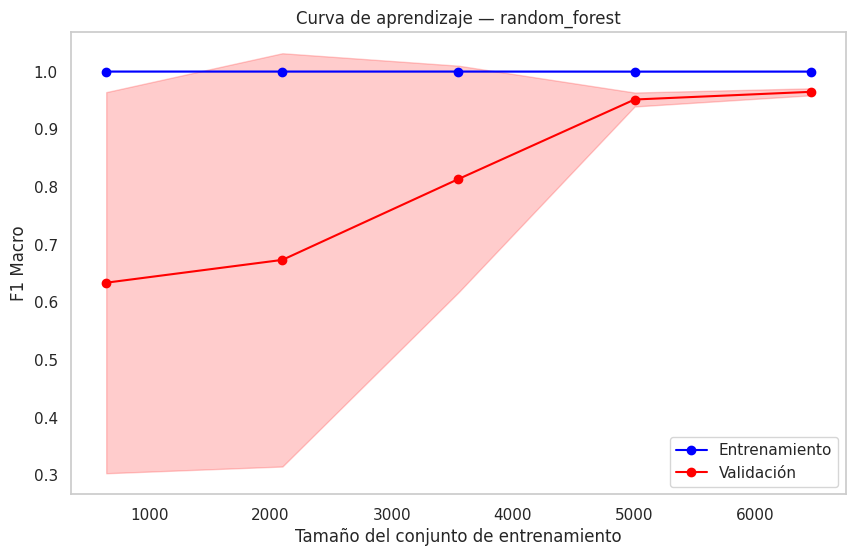

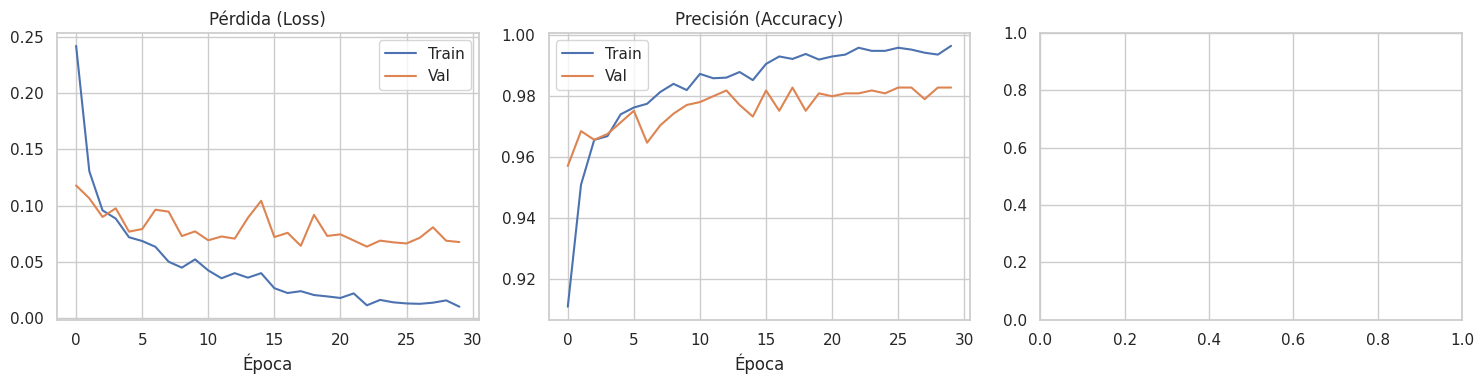

Mejor val_loss: 0.0637 (época 23)
Mejor val_accuracy: 0.9829 (época 18)


In [31]:
# --- 10.1 Importancia de características (Random Forest / XGBoost) ---
if best_model_name in ("random_forest", "xgboost"):
    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_
        feat_names = [f"hist_c{i}" for i in range(96)] + ["mean_r","mean_g","mean_b","std_r","std_g","std_b"] + [f"texture_{i}" for i in range(16)] + ["edge_density","normalized_area"]
        feat_df = pd.DataFrame({"feature": feat_names[:len(importances)], "importance": importances})
        feat_df = feat_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")
        plt.title(f"Top 20 características más importantes — {best_model_name}")
        plt.tight_layout()
        plt.show()
        print("Características más relevantes para la clasificación:")
        display(feat_df.head(10))

# --- 10.2 Curvas de aprendizaje del mejor modelo ---
if best_model_name is not None and hasattr(best_model, "estimator"):
    from sklearn.model_selection import learning_curve
    train_sizes, train_scores, val_scores = learning_curve(
        best_model.estimator if hasattr(best_model, "estimator") else best_model,
        X_train_feat_res, y_train_enc_res, cv=3,
        scoring="f1_macro", n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, "o-", color="blue", label="Entrenamiento")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
    plt.plot(train_sizes, val_mean, "o-", color="red", label="Validación")
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="red")
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("F1 Macro")
    plt.title(f"Curva de aprendizaje — {best_model_name}")
    plt.legend()
    plt.grid()
    plt.show()

# --- 10.3 Curvas de entrenamiento CNN ---
if cnn_history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(cnn_history.history["loss"], label="Train")
    axes[0].plot(cnn_history.history["val_loss"], label="Val")
    axes[0].set_title("Pérdida (Loss)")
    axes[0].set_xlabel("Época")
    axes[0].legend()
    axes[1].plot(cnn_history.history["accuracy"], label="Train")
    axes[1].plot(cnn_history.history["val_accuracy"], label="Val")
    axes[1].set_title("Precisión (Accuracy)")
    axes[1].set_xlabel("Época")
    axes[1].legend()
    if "lr" in cnn_history.history:
        axes[2].plot(cnn_history.history["lr"])
        axes[2].set_title("Tasa de aprendizaje")
        axes[2].set_xlabel("Época")
    plt.tight_layout()
    plt.show()
    print(f"Mejor val_loss: {min(cnn_history.history['val_loss']):.4f} (época {np.argmin(cnn_history.history['val_loss'])+1})")
    print(f"Mejor val_accuracy: {max(cnn_history.history['val_accuracy']):.4f} (época {np.argmax(cnn_history.history['val_accuracy'])+1})")

## 11. Metodología CRISP-DM aplicada

```
┌─────────────────────────────────────────────────────────────┐
│             1. COMPRENSIÓN DEL NEGOCIO                      │
│  • Clasificar calidad de frutas (bueno/regular/malo)       │
│  • Estimar tamaño (pequeño/mediano/grande)                 │
│  • Impacto: reducir desperdicio, estandarizar calidad      │
└──────────────────────┬──────────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────────┐
│             2. COMPRENSIÓN DE LOS DATOS                     │
│  • 23,064 imágenes (11664 bueno, 4612 regular, 6788 malo)  │
│  • Fuentes: Kaggle Fruit Quality + recolección propia       │
│  • Distribución desbalanceada → requiere balanceo           │
└──────────────────────┬──────────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────────┐
│             3. PREPARACIÓN DE LOS DATOS                     │
│  • Redimensionamiento con padding (128×128)                │
│  • Extracción: histogramas color, textura LBP, bordes      │
│  • Balanceo por subcarpeta de fruta + SMOTE                │
│  • División train/val/test (70/15/15) estratificada        │
└──────────────────────┬──────────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────────┐
│             4. MODELADO                                     │
│  • Clásicos: LR, RF, SVM, KNN, XGBoost + GridSearchCV     │
│  • Deep Learning: CNN (4 bloques Conv + BatchNorm)         │
│  • Ajuste hiperparámetros con validación cruzada (3-fold)  │
└──────────────────────┬──────────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────────┐
│             5. EVALUACIÓN                                   │
│  • Métricas: Accuracy, Precision, Recall, F1 (macro/micro) │
│  • Matriz de confusión + ejemplos mal clasificados         │
│  • Curvas de aprendizaje + importancia de características  │
│  • Comparación: mejor clásico (XGBoost) vs CNN             │
└──────────────────────┬──────────────────────────────────────┘
                       ▼
┌─────────────────────────────────────────────────────────────┐
│             6. DESPLIEGUE                                   │
│  • Modelos guardados en outputs_mejorado/                  │
│  • Interfaz Streamlit (app/app.py)                         │
│  • Funciones: predict_image, predict_size, predict_both    │
│  • Captura desde cámara o carga de archivo                 │
└─────────────────────────────────────────────────────────────┘
```

## 12. Arquitectura del sistema

```
┌──────────────┐    ┌────────────────────┐    ┌──────────────────┐
│   Entrada     │    │   Preprocesamiento  │    │    Modelos        │
│              │    │                    │    │                  │
│  Cámara web  │───▶│  Redimensionar     │───▶│  XGBoost (clase) │
│  o archivo   │    │  Padding (128×128) │    │  CNN (clase)     │
│              │    │  Normalizar        │    │  Contornos(tamaño)│
└──────────────┘    └────────────────────┘    └────────┬─────────┘
                                                       ▼
┌──────────────────────────────────────────────────────────────┐
│                    Salida (Streamlit UI)                     │
│  • Calidad: Bueno ✅ / Regular ⚠️ / Malo ❌                 │
│  • Tamaño: Pequeño / Mediano / Grande                       │
│  • Confianza de predicción (%)                              │
└──────────────────────────────────────────────────────────────┘
```

## 13. Análisis de aspectos éticos

### 13.1 Sesgo en los datos
- El dataset contiene desbalanceo natural (más frutas "buenas" que "malas"), mitigado con SMOTE y balanceo por subcarpeta.
- Las imágenes provienen de Kaggle (contexto internacional) más recolección local (Colombia), lo que puede introducir variaciones en iluminación, fondo y tipos de fruta.
- El sistema podría tener menor precisión en frutas o condiciones no representadas en el entrenamiento.

### 13.2 Privacidad y datos
- Las imágenes son de objetos (frutas), no de personas, por lo que no aplican restricciones de datos personales (Ley 1581 de 2012 en Colombia).
- Se recomienda no incluir personas en las imágenes de captura para evitar problemas de privacidad.

### 13.3 Impacto laboral
- La automatización de clasificación puede reemplazar tareas manuales repetitivas, pero también puede complementar el trabajo de los inspectores, reduciendo errores y fatiga.
- Se recomienda un enfoque de aumento (asistencia al humano) en lugar de reemplazo total.

### 13.4 Transparencia
- El modelo es interpretable mediante importancia de características (XGBoost/Random Forest), lo que permite entender qué atributos visuales determinan cada clasificación.
- Para la CNN se proporcionan curvas de entrenamiento y matriz de confusión para evaluar su comportamiento.

### 13.5 Reproducibilidad
- Se fijaron semillas aleatorias (`random_state=42`) en todos los modelos para garantizar resultados reproducibles.
- Los artefactos (modelos, encoder, configuración) se guardan para replicar inferencias.

## 14. Análisis de impactos de la solución

### 14.1 Impacto económico
- **Reducción de desperdicio:** La clasificación temprana de frutas en mal estado evita que contaminen lotes completos durante almacenamiento y transporte.
- **Estandarización:** Elimina la subjetividad de la inspección manual, asegurando calidad consistente para el consumidor.
- **Velocidad:** El procesamiento de una imagen toma < 1 segundo, muy superior a la inspección manual.

### 14.2 Impacto social
- Pequeños agricultores y cooperativas pueden acceder a tecnología de clasificación sin inversión en equipos costosos.
- La interfaz Streamlit funciona en cualquier navegador, sin necesidad de hardware especializado.

### 14.3 Impacto ambiental
- Al reducir el desperdicio de alimentos, se disminuye la huella de carbono asociada a la producción, transporte y descomposición de frutas descartadas innecesariamente.

### 14.4 Limitaciones
- El sistema requiere fondo simple y uniforme para mejor precisión.
- La estimación de tamaño usa área en píxeles (no distancia real), por lo que la distancia de captura debe ser consistente.
- La CNN actualmente tiene menor precisión que XGBoost, lo que sugiere que el feature engineering manual captura mejor las características discriminantes.

## 15. Trabajo futuro y siguientes pasos

1. **Mejorar la CNN:** Aumentar el dataset con más aumentaciones, probar transfer learning (MobileNet, EfficientNet) y ajustar arquitectura.
2. **Simulación en tiempo real:** Implementar en Raspberry Pi con cámara conectada para simular línea de empaque.
3. **Expandir clases:** Agregar más frutas y verduras, así como categorías de calidad más detalladas.
4. **Calibración de tamaño:** Usar un objeto de referencia (moneda) en la imagen para estimar tamaño real en centímetros.
5. **App móvil:** Desplegar el modelo en dispositivo móvil usando TensorFlow Lite.
6. **Dashboard:** Crear dashboard en Streamlit con estadísticas de clasificación históricas.
7. **Video demostrativo:** Grabar video corto (< 10 min) mostrando el flujo completo: carga de imagen → predicción → resultado.

## 16. Referencias

[1] R. Park, "Fruit Quality Classification," Kaggle, 2023. [Online]. Available: https://www.kaggle.com/datasets/ryandpark/fruit-quality-classification

[2] A. Géron, *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, 3rd ed. O'Reilly Media, 2022.

[3] F. Chollet, *Deep Learning with Python*, 2nd ed. Manning Publications, 2021.

[4] C. R. Harris et al., "Array programming with NumPy," *Nature*, vol. 585, pp. 357–362, 2020.

[5] J. D. Hunter, "Matplotlib: A 2D Graphics Environment," *Computing in Science & Engineering*, vol. 9, no. 3, pp. 90–95, 2007.

[6] T. Chen y C. Guestrin, "XGBoost: A Scalable Tree Boosting System," en *Proc. 22nd ACM SIGKDD*, 2016, pp. 785–794.

[7] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, no. 1, pp. 5–32, 2001.

[8] N. V. Chawla et al., "SMOTE: Synthetic Minority Over-sampling Technique," *Journal of Artificial Intelligence Research*, vol. 16, pp. 321–357, 2002.

[9] Ley 1581 de 2012, "Por la cual se dictan disposiciones generales para la protección de datos personales," Congreso de Colombia, 2012.

[10] Imágenes recolectadas por el grupo de trabajo (2026) en plazas de mercado y supermercados locales.